# Our Logs

In [1]:
import json
from datetime import datetime
import pandas as pd


In [2]:
tasks = []
submissions = []
with open('modified_log.txt') as LOGS:
    for line in LOGS.readlines():
        if line[0] == '2': #timestamps
            time = datetime.strptime(line, "%Y%m%d_%H%M%S\n")
        else:
            query = json.loads(line)
            if "task" in query["query"]["current"]:
                if len(submissions) > 1:
                    tasks.append(submissions)
                submissions = []
            submissions.append((time, query)) #Start time approx = submissions[1]
if submissions:
    tasks.append(submissions)

FileNotFoundError: [Errno 2] No such file or directory: 'modified_log.txt'

In [3]:
def get_starttime(task):
    return task[1][0]

def get_taskname(task):
    return task[0][1]['query']['current']

def get_success_index(task):
    for i, submission in enumerate(task):
        if len(submission) <=1 :
            print(submission)
        if submission[1]['query']['current'] == 'yay':
            return i - 1
    return -1

def get_success_time(task):
    success = get_success_index(task)
    if success > 0:
        return (task[success + 1][0] - get_starttime(task)).seconds
    return -1

def get_wrong_tries(task):
    success = get_success_index(task)
    if success > 0:
        return success - 1
    return -1

def get_query_presentation(query):
    text = query["current"]
    if query["before"]:
        if query["beforewhen"]:
            text = f'{query["before"]}({query["beforewhen"]}) - ' + text
        else:
            ext = f'{query["before"]} - '+ text
    if query["after"]:
        if query["afterwhen"]:
            text += f' - {query["after"]}({query["afterwhen"]})'
        else:
            text += f' - {query["after"]}'
    return text

def get_correct_query(task):
    success = get_success_index(task)
    if success > 0:
        return get_query_presentation(task[success][1]["query"])
    return ""

def use_time_relation(task):
    success = get_success_index(task)
    if success > 0:
        return task[success][1]["query"]["before"] != "" or task[success][1]["query"]["after"] != ""
    return None

def use_ocr(task):
    success = get_success_index(task)
    if success > 0:
        return '"' in task[success][1]["query"]["current"]
    return None


In [4]:
COLUMNS = {"starttime": get_starttime,
           "taskname": get_taskname,
           "success_index": get_success_index,
           "success_time": get_success_time,
           "wrong_tries": get_wrong_tries,
           "correct_query": get_correct_query,
           "temporal_relation": use_time_relation,
           "use_ocr": use_ocr
           }
print(len(tasks))
data = {}
for name, func in COLUMNS.items():
    data[name] = [func(task) for task in tasks]
data["use_location"] = [i + 1 in [1, 7, 10, 11, 16, 18, 19, 23] for i in range(len(tasks))]
# data["use_browsing"] = [i + 1 in []] #TODO!
df = pd.DataFrame(data=data)

0


In [5]:
df

,starttime,taskname,success_index,success_time,wrong_tries,correct_query,temporal_relation,use_ocr,use_location


In [ ]:
import seaborn as sns
sns.histplot(data=df, x="success_time", bins=10, hue="use_ocr")

In [ ]:
def get_correct_query(task):
    success = get_success_index(task)
    if success:
        return task[success][1]["query"]
    else:
        return None

for task in tasks:
    print(get_taskname(task), get_correct_query(task))

# Luka's Log

In [6]:
import json
offical_run = json.load(open("Official Run.json"))
# 'id', 'name', 'description', 'started', 'ended', 'tasks', 'hasStarted', 'running', 'hasEnded'

In [7]:
descriptions = offical_run['description']
# 'id', 'name', 'description', 'taskTypes', 'taskGroups', 'tasks', 'teams', 'teamGroups', 'participantCanView'
tasks = descriptions['tasks']
# list of ['id', 'name', 'taskGroup', 'taskType', 'duration', 'mediaCollectionId', 'target', 'hints']
targets = {}
queries = {}
for i in range(len(tasks)):
    targets[tasks[i]['name']] = [item['location'] for item in tasks[i]['target']['items']]
    queries[tasks[i]['name']] = [item['text'] for item in tasks[i]['hints']]

In [8]:
queries

{'Task 01': ['I was building a computer alone in the early morning on a Friday...',
  'I was building a computer alone in the early morning on a Friday at a desk...',
  'I was building a computer alone in the early morning on a Friday at a desk with a blue background...',
  'I was building a computer alone in the early morning on a Friday at a desk with a blue background. Sometimes I needed to refer to the manual...',
  'I was building a computer alone in the early morning on a Friday at a desk with a blue background. Sometimes I needed to refer to the manual. I remember some Chinese posters on the desk background...',
  'I was building a computer alone in the early morning on a Friday at a desk with a blue background. Sometimes I needed to refer to the manual. I remember some Chinese posters on the desk background. I was in Dublin City University in 2015.'],
 'Task 02': ['I was going into Northside Shopping Centre... ',
  'I was going into Northside Shopping Centre. I was there to get

In [9]:
teams = offical_run['description']['teams']
# list of ['uid', 'name', 'color', 'logoId', 'users']
team_ids = {item["uid"]["string"]: item["name"] for item in teams}

In [10]:
team_ids.values()
TEAMS = ['MySceal', 'SomHunter+', 'LifeSeeker', 'Voxento', 'CVHunter', 'Memento', 'FIRST', 'NTU-ILRS', 'lifeXplore', 'LifeMon', 'vitrivr', 'vitrivr-VR', 'XQC', 'Exquisitor', 'PhotoCube', 'ViRMA', 'LifeGraph']

In [11]:
tasks = offical_run['tasks']
# list of ['started', 'ended', 'submissions', 'description', 'filter', 'scorer', 'validator', 'duration', 'uid',
#          'taskDescriptionId', 'position', 'hasStarted', 'running', 'hasEnded', 'teamGroupAggregators']
# ['teamId', 'memberId', 'timestamp', 'item', 'uid', 'status']
submissions = {}
start_times = {}
memento = []
real_queries = []
real_targets = []
for i in range(23):
    real_queries.append(queries[tasks[i]["description"]["name"]])
    real_targets.append(targets[tasks[i]["description"]["name"]])
    start_times[i] = tasks[i]["started"]
    submissions[i] = [(team_ids[item["teamId"]["string"]],
                       item["status"],
                       (item["timestamp"] - start_times[i])/1000,
                      item["item"]["name"]) for item in tasks[i]['submissions']]
    for item in tasks[i]['submissions']:
        if team_ids[item["teamId"]["string"]] == "MySceal":
            memento.append(({"query": i,
                             "image": item["item"]["name"],
                             "time": (item["timestamp"] - start_times[i]) / 1000,
                             "status": item["status"]}))
json.dump({"submissions": submissions, "memento": memento, "queries": real_queries}, open("memento.log", "w"))

In [12]:
## THIS IS WHAT YOU NEED
submissions[4]

[('FIRST', 'CORRECT', 31.421, '20160927_122742_000'),
 ('vitrivr', 'CORRECT', 35.817, '20160927_122012_000'),
 ('MySceal', 'CORRECT', 40.976, '20160927_123022_000'),
 ('NTU-ILRS', 'CORRECT', 43.055, '20160927_122012_000'),
 ('LifeSeeker', 'WRONG', 44.037, '20160919_111228_000'),
 ('LifeMon', 'WRONG', 49.229, 'b00000736_21i6bq_20150225_133002e'),
 ('vitrivr-VR', 'WRONG', 49.765, '20160913_112159_000'),
 ('LifeMon', 'WRONG', 58.45, 'b00000737_21i6bq_20150225_133036e'),
 ('vitrivr-VR', 'CORRECT', 59.702, '20160927_122012_000'),
 ('LifeSeeker', 'CORRECT', 67.45, '20160927_122012_000'),
 ('LifeMon', 'WRONG', 69.363, 'b00000739_21i6bq_20150225_133146e'),
 ('Memento', 'WRONG', 70.024, '20160927_120741_000'),
 ('Voxento', 'CORRECT', 90.732, '20160927_122148_000'),
 ('LifeMon', 'WRONG', 116.225, 'b00000760_21i6bq_20150224_142557e'),
 ('SomHunter+', 'CORRECT', 119.087, '20160927_122220_000'),
 ('Memento', 'CORRECT', 120.101, '20160927_122220_000'),
 ('LifeMon', 'WRONG', 144.623, 'b00000707_21i6b

In [13]:
real_queries[0] # query 1

['I was building a computer alone in the early morning on a Friday...',
 'I was building a computer alone in the early morning on a Friday at a desk...',
 'I was building a computer alone in the early morning on a Friday at a desk with a blue background...',
 'I was building a computer alone in the early morning on a Friday at a desk with a blue background. Sometimes I needed to refer to the manual...',
 'I was building a computer alone in the early morning on a Friday at a desk with a blue background. Sometimes I needed to refer to the manual. I remember some Chinese posters on the desk background...',
 'I was building a computer alone in the early morning on a Friday at a desk with a blue background. Sometimes I needed to refer to the manual. I remember some Chinese posters on the desk background. I was in Dublin City University in 2015.']

In [14]:
json.dump({"queries": real_queries, "targets": real_targets}, open('LSC21queries.json', 'w'))

## Correct/Incorrect

In [15]:
from collections import defaultdict
correct_counts = defaultdict(int)
incorrect_counts = defaultdict(int)
total_counts = defaultdict(int)
time_till_correct = defaultdict(lambda: defaultdict(lambda: None))
time_till_correct_full = defaultdict(lambda: defaultdict(lambda: 300))
top_3 = defaultdict(int)
for i in range(23):
    correct_time = 0
    for team, status, time, image in submissions[i]:
        if status == "CORRECT":
            correct_counts[team] += 1
            if time_till_correct[team][i]:
                time_till_correct[team][i] = min(time_till_correct[team][i], time)
            else:
                time_till_correct[team][i] = time
            time_till_correct_full[team][i] = min(time_till_correct_full[team][i], time)

            correct_time += 1
            if correct_time <= 3:
                top_3[team] += 1
        else:
            incorrect_counts[team] += 1

        total_counts[team] += 1

In [16]:
with open('lsc_score_time.csv') as f:
    lines = f.readlines()
    team_names = lines[0].strip().split(',')[1:]
    final_scores = lines[-1].strip().split(',')[1:]
sorted_scores = sorted(zip(team_names, final_scores), key=lambda x:-float(x[1]))
print([(t,s) for t,s in sorted_scores])

FileNotFoundError: [Errno 2] No such file or directory: 'lsc_score_time.csv'

### Scoring

In [ ]:
# Scores for each queries
max_point = 100
max_point_end = 50
penalty = 10
scores = []
for submission in submissions.values():
    score = defaultdict(float)
    for team, status, time, image in submission:
        if status == "WRONG":
            score[team] -= penalty
        else:
            score[team] += max_point_end + (max_point - max_point_end) * (1 - time/300)
    for team in TEAMS:
        score[team] = max(0, score[team])
    scores.append(score)

In [ ]:
cum_scores = defaultdict(float)
normalize_scores = {}
for score in scores:
    for team in score:
        cum_scores[team] += score[team]
max_score = max(cum_scores.values())
for team in cum_scores:
    normalize_scores[team] = cum_scores[team]/max_score * 100
print([(team, normalize_scores[team]) for team in TEAMS])

[('MySceal', 100.0), ('SomHunter+', 97.63207134463812), ('LifeSeeker', 96.99040260282766), ('Voxento', 91.43347400678529), ('CVHunter', 77.29342865593327), ('Memento', 77.19807073440559), ('FIRST', 55.49094473738862), ('NTU-ILRS', 48.2992287737204), ('lifeXplore', 47.44165157967009), ('LifeMon', 38.703628847313986), ('vitrivr', 32.49468435946207), ('vitrivr-VR', 27.656197033837778), ('XQC', 21.49227719266861), ('Exquisitor', 21.227614548716225), ('PhotoCube', 19.422680973575396), ('ViRMA', 15.948791580661178), ('LifeGraph', 11.50305962939958)]


In [ ]:
# [('MySceal', '100'), ('SomHunter+', '97.63207134463812'), ('LifeSeeker', '96.99040260282761'), ('Voxento', '91.43347400678527'), ('CVHunter', '77.29342865593325'), ('Memento', '77.19807073440559'), ('FIRST', '55.4909447373886'), ('NTU-ILRS', '48.299228773720394'), ('lifeXplore', '47.441651579670086'), ('LifeMon', '38.703628847313986'), ('vitrivr', '32.49468435946206'), ('vitrivr-VR', '27.656197033837774'), ('XQC', '21.492277192668602'), ('Exquisitor', '21.22761454871622'), ('PhotoCube', '19.422680973575392'), ('ViRMA', '15.948791580661176'), ('LifeGraph', '11.503059629399576')]

### OCR scores

In [ ]:
OCR_queries = {1: ['Northside Shopping Centre', 0],
 3: ['I love bicycle', 1],
 6: ['no more junk mail', 2],
 8: ['Maple Leaf', 2],
 9: ['Volvo, Mazda?', 2],
 11: ['Omron, Braun', 2],
 13: ["TagHeuer", 0],
 14: ['PVG', 0, 'name', 3, 'FRA to PVG', 4],
 18: ['€2.99', 1, 'SPAR', 3],
 19: ["SPAR", 2, "Tasty Deli", 3],
 20: ["Quantified Self", 4]
}

In [ ]:
real_queries[0]

['I was building a computer alone in the early morning on a Friday...',
 'I was building a computer alone in the early morning on a Friday at a desk...',
 'I was building a computer alone in the early morning on a Friday at a desk with a blue background...',
 'I was building a computer alone in the early morning on a Friday at a desk with a blue background. Sometimes I needed to refer to the manual...',
 'I was building a computer alone in the early morning on a Friday at a desk with a blue background. Sometimes I needed to refer to the manual. I remember some Chinese posters on the desk background...',
 'I was building a computer alone in the early morning on a Friday at a desk with a blue background. Sometimes I needed to refer to the manual. I remember some Chinese posters on the desk background. I was in Dublin City University in 2015.']

In [ ]:
json.dump(real_queries, open("real_queries.json", "w"))
json.dump(real_targets, open("real_targets.json", "w"))

In [ ]:
ocr_scores = defaultdict(float)
for i, score in enumerate(scores):
    if (i+1) in OCR_queries:
        for team in score:
            ocr_scores[team] += score[team]

In [ ]:
time_ocr = defaultdict(lambda: defaultdict(lambda: None))
for i in OCR_queries:
    for team, status, time, image in submissions[i]:
        if status == "CORRECT":
            time_ocr[team][i] = time - OCR_queries[i][1] * 30

# GRAPHS

In [ ]:
data = {
    "team": TEAMS,
    "correct": [correct_counts[team] for team in TEAMS],
    "incorrect": [incorrect_counts[team] for team in TEAMS],
    "precision": [correct_counts[team]/total_counts[team] for team in TEAMS],
    "recall": [correct_counts[team]/23 for team in TEAMS],
    "top_3": [top_3[team] for team in TEAMS],
    "cum_score": [cum_scores[team] for team in TEAMS],
    "norm_score": [normalize_scores[team] for team in TEAMS],
    "ocr_score": [ocr_scores[team] for team in TEAMS],
    "non_ocr_score": [cum_scores[team] - ocr_scores[team] for team in TEAMS]
}
for i in range(23):
    data[f"time_correct_{i}"] = [time_till_correct[team][i] for team in TEAMS]
for i in range(23):
    data[f"time_correct_full_{i}"] = [time_till_correct_full[team][i] for team in TEAMS]
# for i in OCR_queries:
    # data[f"time_correct_ocr_{i}"] = [time_ocr[team][i] for team in TEAMS]

In [ ]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame(data=data)
df[df.columns[:8]]
df.to_csv('lsc.table', index=False)

In [ ]:
df

,team,correct,incorrect,precision,recall,top_3,cum_score,norm_score,ocr_score,non_ocr_score,...,time_correct_full_13,time_correct_full_14,time_correct_full_15,time_correct_full_16,time_correct_full_17,time_correct_full_18,time_correct_full_19,time_correct_full_20,time_correct_full_21,time_correct_full_22
0,MySceal,19,4,0.826087,0.826087,12,1604.306500,100.000000,756.364833,847.941667,...,16.840,222.688,88.475,300.000,207.853,119.149,139.983,39.019,300.000,52.849
1,SomHunter+,19,9,0.678571,0.826087,12,1566.317667,97.632071,726.114000,840.203667,...,18.444,300.000,56.942,87.566,294.389,300.000,237.829,195.202,300.000,46.238
2,LifeSeeker,20,6,0.769231,0.869565,9,1556.023333,96.990403,696.012167,860.011167,...,16.940,94.394,112.491,300.000,300.000,120.762,203.793,292.949,171.276,110.393
3,Voxento,18,3,0.857143,0.782609,11,1466.873167,91.433474,671.707667,795.165500,...,144.637,216.911,29.129,300.000,203.803,84.281,300.000,104.149,300.000,40.551
4,CVHunter,15,8,0.652174,0.652174,5,1240.023500,77.293429,683.915667,556.107833,...,25.382,300.000,132.321,300.000,300.000,232.776,127.525,154.436,300.000,40.976
5,Memento,16,11,0.592593,0.695652,9,1238.493667,77.198071,501.731500,736.762167,...,83.508,300.000,37.890,131.055,241.849,119.413,221.076,300.000,286.390,46.221
6,FIRST,12,13,0.480000,0.521739,4,890.244833,55.490945,251.860167,638.384667,...,147.043,300.000,34.810,198.717,300.000,300.000,200.061,85.673,58.019,126.033
7,NTU-ILRS,12,17,0.413793,0.521739,1,774.867667,48.299229,359.681833,415.185833,...,300.000,300.000,202.549,223.019,300.000,300.000,260.048,242.756,137.979,240.872
8,lifeXplore,12,13,0.480000,0.521739,2,761.109500,47.441652,445.636500,315.473000,...,225.208,226.000,300.000,300.000,300.000,293.739,87.453,300.000,300.000,300.000
9,LifeMon,10,8,0.555556,0.434783,0,620.924833,38.703629,159.603000,461.321833,...,300.000,300.000,227.781,232.378,300.000,300.000,300.000,217.418,300.000,233.802


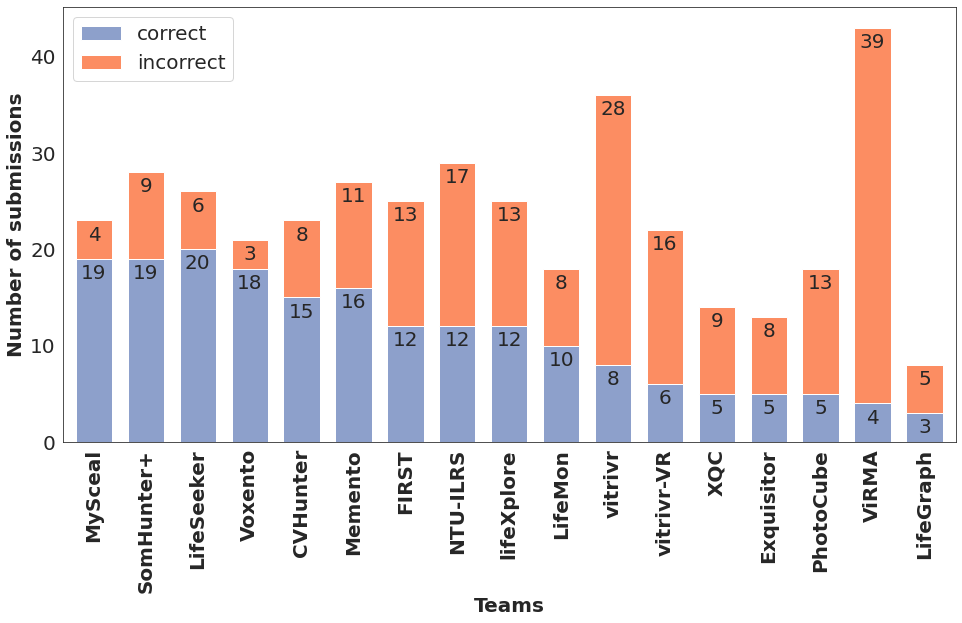

In [ ]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")
plt.rcParams.update({'font.size': 20})

ax = df[["team", "correct", "incorrect"]].plot(x='team', kind='bar', stacked=True, figsize=(16, 8), width=0.7, color=["#8da0cb", "#fc8d62"])
ax.bar_label(ax.containers[0], label_type='edge', padding=-24)
ax.bar_label(ax.containers[1], labels=df["incorrect"], label_type='edge', padding=-24)

plt.xlabel("Teams", fontweight='bold')
plt.ylabel("Number of submissions", fontweight='bold')
plt.xticks(fontweight='bold')
plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("incorrect_correct.png", format="png", bbox_inches='tight')

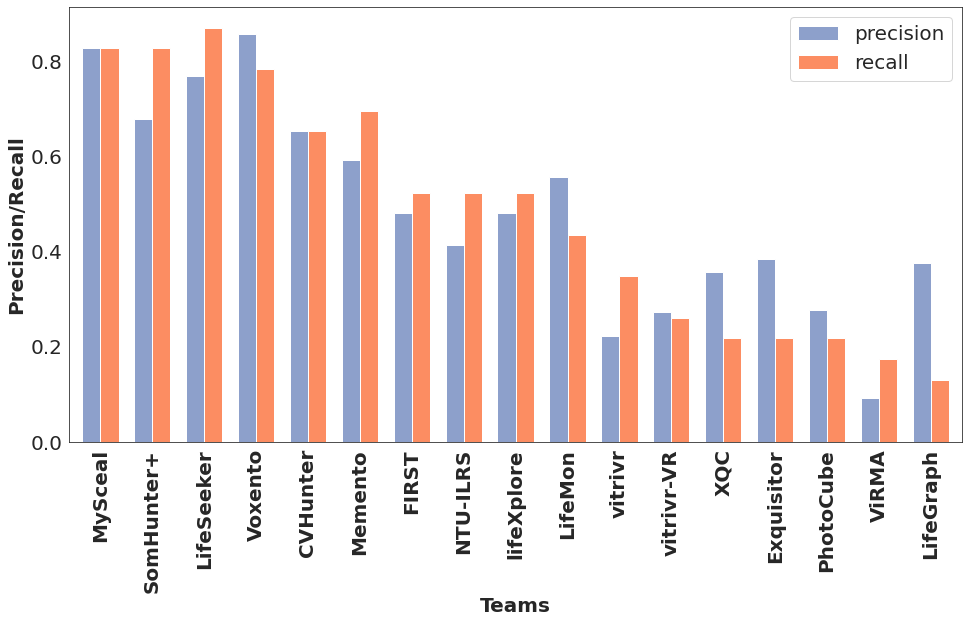

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_style("white")
plt.rcParams.update({'font.size': 20})

df[["team", "precision", "recall"]].plot(x='team', kind='bar', figsize=(16, 8),width=0.7, color=["#8da0cb", "#fc8d62"])
plt.xlabel("Teams", fontweight='bold')
plt.ylabel("Precision/Recall", fontweight='bold')
plt.xticks(fontweight='bold')
plt.savefig("precision-recall.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("precision-recall.png", format="png", bbox_inches='tight')

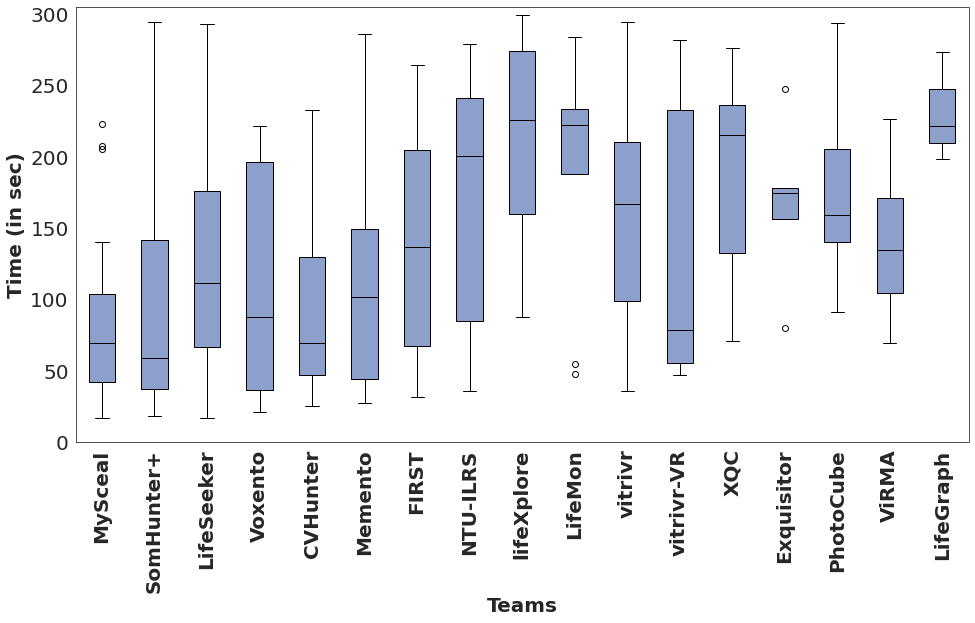

In [ ]:
blue = sns.color_palette()[0]
sns.set_style("white")

ax = df[[f"time_correct_{i}" for i in range(23)]].T.plot(kind='box',
    figsize=(16, 8), showmeans=False, showfliers=True,
    boxprops=dict(facecolor="#8da0cb", color="black", linewidth=1),
    medianprops=dict(color="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1),
    capprops=dict(color="black", linewidth=1),
    flierprops=dict(marker='o', markersize=6, color="#8da0cb"),
    patch_artist=True)
plt.xlabel("Teams", fontweight='bold')
plt.ylabel("Time (in sec)", fontweight='bold')
plt.xticks(fontweight='bold')


ax.set_xticklabels(TEAMS)
ax.set_ylim([0, 305])
plt.xticks(rotation="vertical")
plt.savefig("time.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("time.png", format="png", bbox_inches='tight')

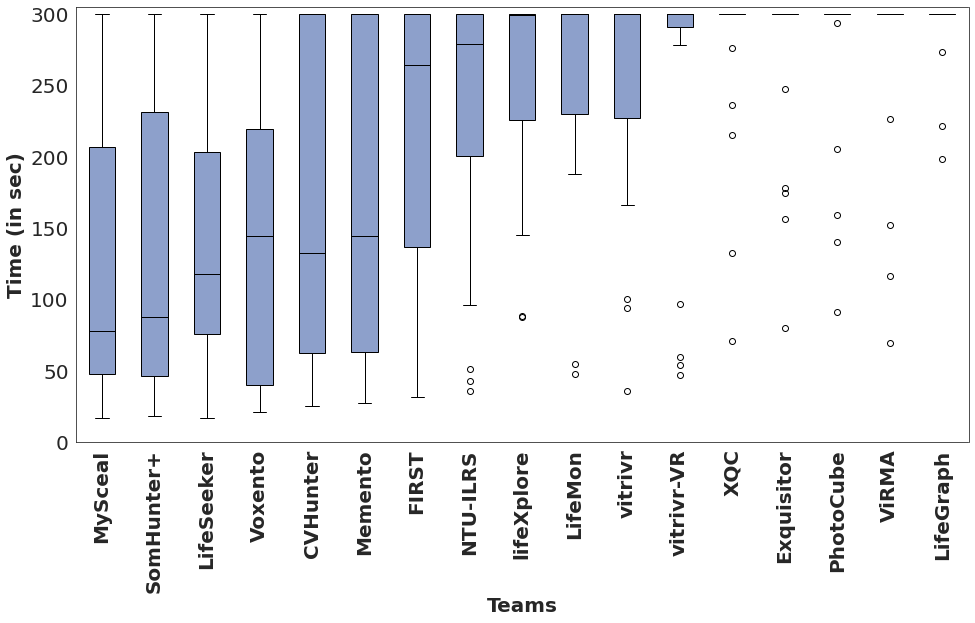

In [ ]:
blue = sns.color_palette()[0]
sns.set_style("white")

ax = df[[f"time_correct_full_{i}" for i in range(23)]].T.plot(kind='box',
    figsize=(16, 8), showmeans=False, showfliers=True,
    boxprops=dict(facecolor="#8da0cb", color="black", linewidth=1),
    medianprops=dict(color="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1),
    capprops=dict(color="black", linewidth=1),
    flierprops=dict(marker='o', markersize=6, color="#8da0cb"),
    patch_artist=True)
plt.xlabel("Teams", fontweight='bold')
plt.ylabel("Time (in sec)", fontweight='bold')
plt.xticks(fontweight='bold')


ax.set_xticklabels(TEAMS)
ax.set_ylim([0, 305])
plt.xticks(rotation="vertical")
plt.savefig("speed.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("speed.png", format="png", bbox_inches='tight')

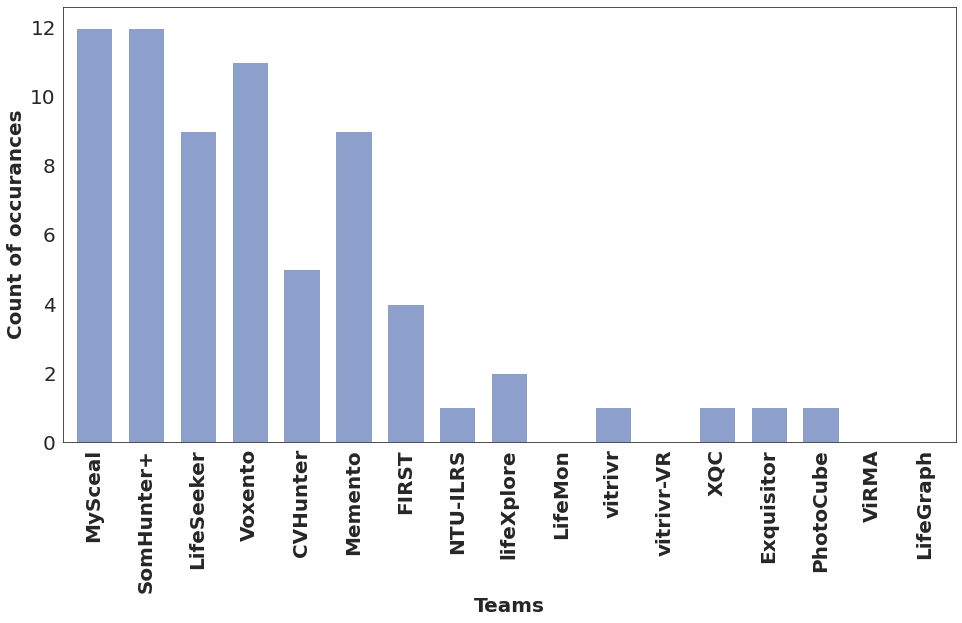

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_style("white")
df[["team", "top_3"]].plot(x='team', kind='bar', figsize=(16, 8), legend = False, color=["#8da0cb"], width=0.7)
plt.xlabel("Teams", fontweight="bold")
plt.ylabel("Count of occurances", fontweight="bold")
plt.xticks(fontweight="bold")
plt.savefig("top3.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("top3.png", format="png", bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


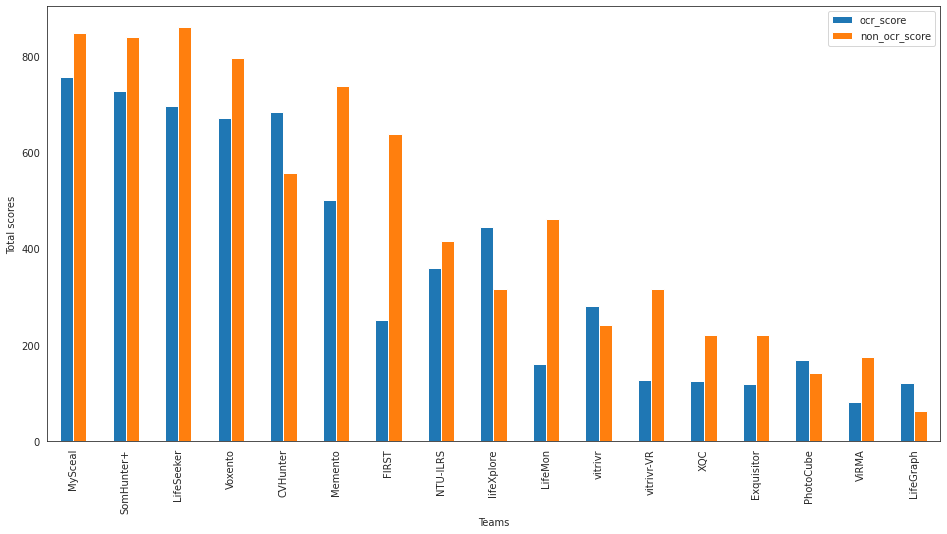

In [ ]:
import seaborn as sns
sns.set_style("white")

df[["team", "ocr_score", "non_ocr_score"]].plot(x='team', kind='bar', figsize=(16, 8))
plt.xlabel("Teams")
plt.ylabel("Total scores")
plt.savefig("ocr_score.eps", format="eps", bbox_inches='tight', dpi=1200)

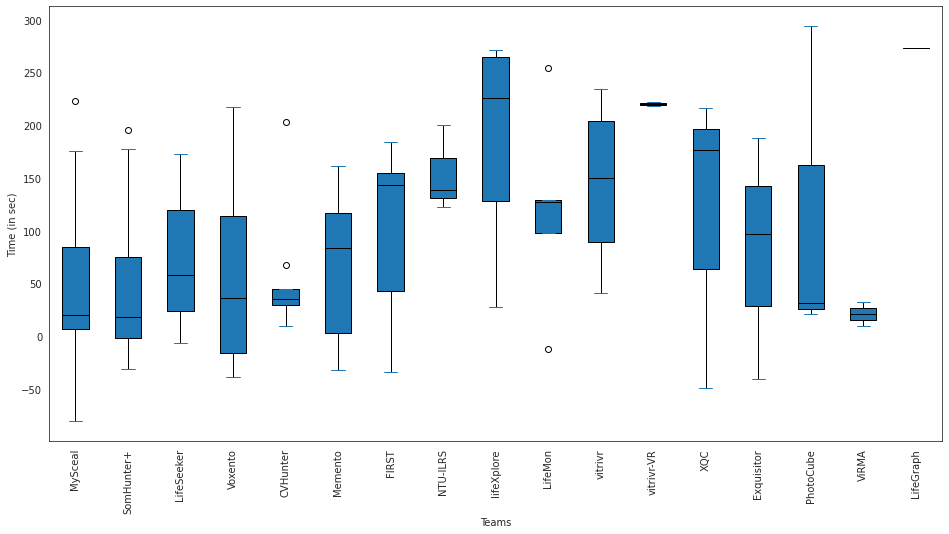

In [ ]:
blue = sns.color_palette()[0]
ax = df[[f"time_correct_ocr_{i}" for i in OCR_queries]].T.plot(kind='box',
    figsize=(16, 8), showmeans=False, showfliers=True,
    boxprops=dict(facecolor=blue, color="black", linewidth=1),
    medianprops=dict(color="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1),
    flierprops=dict(marker='o', markersize=6, color=blue),
    patch_artist=True)
plt.xlabel("Teams")
plt.ylabel("Time (in sec)")
ax.set_xticklabels(TEAMS)
plt.xticks(rotation="vertical")
plt.savefig("time.eps", format="eps", bbox_inches='tight', dpi=1200)

# Query analysis

## Wrong answers

In [ ]:
wrongs = []
total_wrongs = []
total_submissions = []
total_corrects = []
for submission in submissions.values():
    wrong = defaultdict(int)
    num = 0
    total = 0
    for _, status, _, image in submission:
        if status == "WRONG":
            wrong[image] += 1
            num +=1
        total += 1
    total_wrongs.append(num)
    total_submissions.append(total)
    total_corrects.append(total-num)
    wrongs.append((num, total, {image: time for image, time in wrong.items() if time > 1}))

In [ ]:
real_queries[3]

['There was a while t-shirt for sale...',
 'There was a while t-shirt for sale. I remember it said I love bicycle. ..',
 'There was a while t-shirt for sale. I remember it said I love bicycle. It was in a bicycle and parts store...',
 'There was a while t-shirt for sale. I remember it said I love bicycle. It was in a bicycle and parts store. A big sale, bicycles were half price...',
 'There was a while t-shirt for sale. I remember it said I love bicycle. It was in a bicycle and parts store. A big sale, bicycles were half price. It was in the afternoon… before I drove to another store then drove to my home...',
 'There was a while t-shirt for sale. I remember it said I love bicycle. It was in a bicycle and parts store. A big sale, bicycles were half price. It was in the afternoon… on the 15th May 2015.']

In [ ]:
query_data = {
    "query": [f"Query {i+1}" for i in range(23)],
    "incorrect": total_wrongs,
    "submission": total_submissions,
    "correct": total_corrects
}
query_df = pd.DataFrame(data=query_data)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


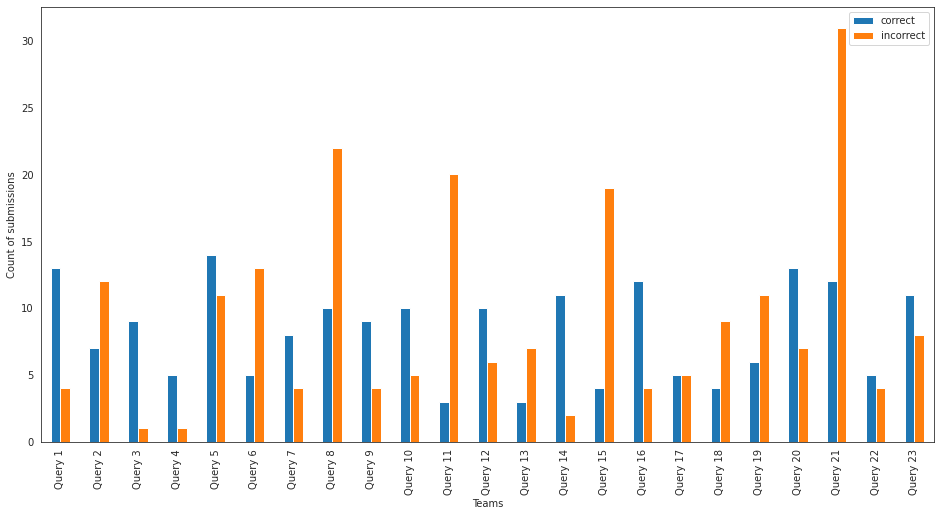

In [ ]:
query_df[["query", "correct", "incorrect"]].plot(x='query', kind='bar', figsize=(16, 8))
plt.xlabel("Teams")
plt.ylabel("Count of submissions")
plt.savefig("correct-incorrect query.eps", format="eps", bbox_inches='tight', dpi=1200)

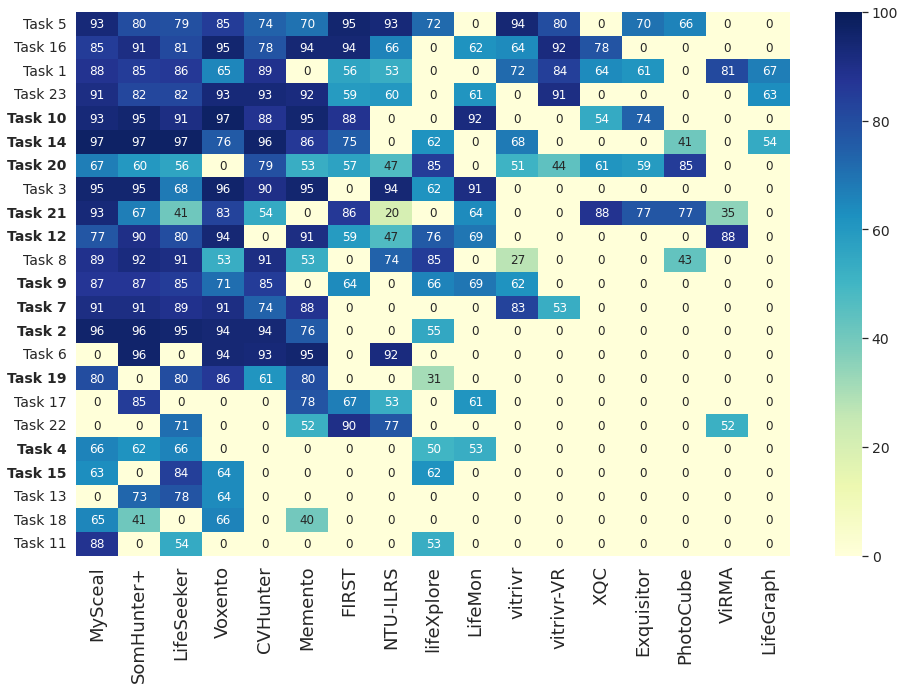

In [ ]:
import numpy as np

sum_score_per_task = []
for score in scores:
    sum_score_per_task.append(sum([score[team] for team in TEAMS]))
sum_score_per_task
sorted_task = [task for task, score in sorted(zip(range(23), sum_score_per_task), key=lambda x:-x[1])]
sns.set(rc={'figure.figsize':(16,10), 'font.size': 14})
plt.rcParams.update({'font.size': 12})

data_matrix = [[np.round(scores[i][team]) for team in TEAMS] for i in sorted_task]
ax = sns.heatmap(data_matrix,
                 vmin=0, vmax=100, cmap="YlGnBu",
                 annot=True,
                 xticklabels=TEAMS,
                 yticklabels=[f"Task {i+1}" for i in sorted_task])

plt.xticks(rotation="vertical", fontsize=18)
plt.yticks(rotation="horizontal", fontsize=14)
for i in OCR_queries:
    ax.get_yticklabels()[sorted_task.index(i)].set_weight("bold")
cbar = ax.collections[0].colorbar

cbar.ax.tick_params(labelsize=14)
plt.savefig("task_team_score.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("task_team_score.png", format="png", bbox_inches='tight')

In [ ]:
real_queries[10]

['Telescope in the mirror before going to the airport... ',
 'Telescope in the mirror before going to the airport. I was able to see my telescope and a red flower vase in the mirror in my bedroom...',
 'Telescope in the mirror before going to the airport. I was able to see my telescope and a red flower vase in the mirror in my bedroom. I also remember a white violin...',
 'Telescope in the mirror before going to the airport. I was able to see my telescope and a red flower vase in the mirror in my bedroom. I also remember a white violin, flowers and a nice painting... ',
 'Telescope in the mirror before going to the airport. I was able to see my telescope and a red flower vase in the mirror in my bedroom. I also remember a white violin, flowers and a nice painting. I was playing with my computer and phone at the time... ',
 'Telescope in the mirror before going to the airport. I was able to see my telescope and a red flower vase in the mirror in my bedroom. I also remember a white violi

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
        22.5]),
 [Text(0, 0.5, 'Task 5'),
  Text(0, 1.5, 'Task 16'),
  Text(0, 2.5, 'Task 1'),
  Text(0, 3.5, 'Task 23'),
  Text(0, 4.5, 'Task 10'),
  Text(0, 5.5, 'Task 14'),
  Text(0, 6.5, 'Task 20'),
  Text(0, 7.5, 'Task 3'),
  Text(0, 8.5, 'Task 21'),
  Text(0, 9.5, 'Task 12'),
  Text(0, 10.5, 'Task 8'),
  Text(0, 11.5, 'Task 9'),
  Text(0, 12.5, 'Task 7'),
  Text(0, 13.5, 'Task 2'),
  Text(0, 14.5, 'Task 6'),
  Text(0, 15.5, 'Task 19'),
  Text(0, 16.5, 'Task 17'),
  Text(0, 17.5, 'Task 22'),
  Text(0, 18.5, 'Task 4'),
  Text(0, 19.5, 'Task 15'),
  Text(0, 20.5, 'Task 13'),
  Text(0, 21.5, 'Task 18'),
  Text(0, 22.5, 'Task 11')])

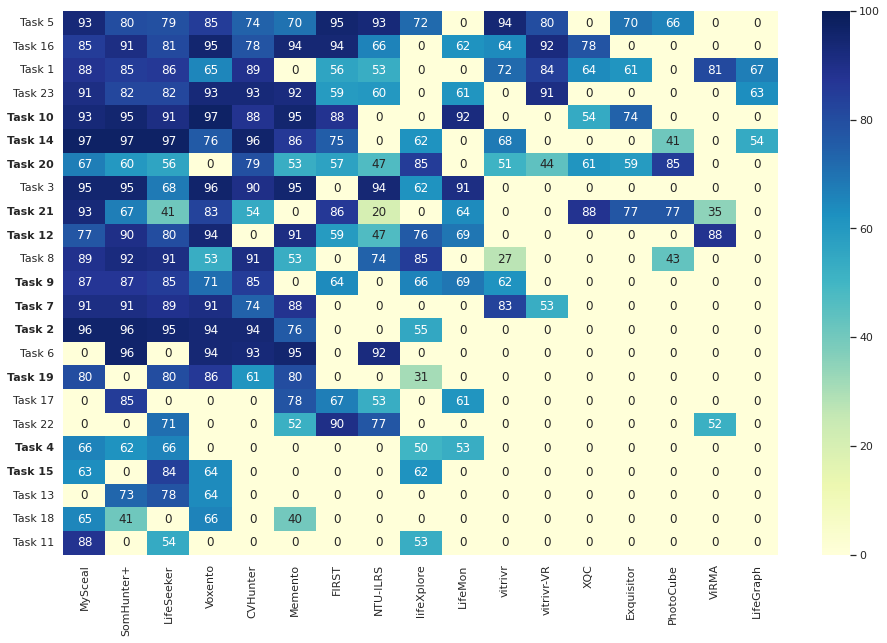

In [ ]:
sns.set(rc={'figure.figsize':(16,10)})
ax = sns.heatmap(data_matrix,
                 vmin=0, vmax=100, cmap="YlGnBu",
                 annot=True)
ax.set_xticklabels(TEAMS)
ax.set_yticklabels([f"Task {i+1}" for i in sorted_task])
for i in OCR_queries:
    ax.get_yticklabels()[sorted_task.index(i)].set_weight("bold")
plt.xticks(rotation="vertical")
plt.yticks(rotation="horizontal")

In [ ]:
OCR_queries.keys()

dict_keys([1, 3, 6, 8, 9, 11, 13, 14, 18, 19, 20])

In [ ]:
real_queries[10]

['Telescope in the mirror before going to the airport... ',
 'Telescope in the mirror before going to the airport. I was able to see my telescope and a red flower vase in the mirror in my bedroom...',
 'Telescope in the mirror before going to the airport. I was able to see my telescope and a red flower vase in the mirror in my bedroom. I also remember a white violin...',
 'Telescope in the mirror before going to the airport. I was able to see my telescope and a red flower vase in the mirror in my bedroom. I also remember a white violin, flowers and a nice painting... ',
 'Telescope in the mirror before going to the airport. I was able to see my telescope and a red flower vase in the mirror in my bedroom. I also remember a white violin, flowers and a nice painting. I was playing with my computer and phone at the time... ',
 'Telescope in the mirror before going to the airport. I was able to see my telescope and a red flower vase in the mirror in my bedroom. I also remember a white violi

#NTCIR

In [ ]:
from collections import defaultdict
ground_truths = defaultdict(list)
with open('qrels_final.txt') as f:
    for line in f.readlines():
        query, _, image_id, _ = line.split(' ')
        ground_truths[query].append(image_id.strip())

FileNotFoundError: ignored

In [ ]:
[len(gt) for gt in ground_truths.values()]

In [ ]:
def calc_map(subs, ground_truth):
    rel_so_far = 0
    sum = 0
    for i, sub in enumerate(subs):
        if sub:
            rel_so_far += 1
            sum += rel_so_far / (i + 1)
    if rel_so_far:
        return sum/min(100, len(ground_truth))
    return 0
def calc_prec(subs, num):
    return sum(subs[:num])/num

In [ ]:
submissions = defaultdict(list)
solved = defaultdict(list)
with open('DCU-DCUMYSCEAL01-Automatic.csv') as f:
    lines = f.readlines()[1:]
    for line in lines:
        _, _, topic_id, image_id, *_ = line.split(',')
        # if int(topic_id) > 16024:
            # break
        image_id = image_id.strip().lower()
        submissions[topic_id].append(image_id in ground_truths[topic_id])
        solved[topic_id] = True in submissions[topic_id]

In [ ]:
topics = list(submissions.keys())
score = []
for topic in topics:
    map = calc_map(submissions[topic], ground_truths[topic])
    # print(topic, map)
    prec = calc_prec(submissions[topic], 10)
    score.append(map)
sum(score)/len(score)

In [ ]:
#num ret
sum([len(sub) for sub in submissions.values()])

In [ ]:
#num queries solved
sum(solved.values())

In [ ]:
# num_rel_ret
sum([sum(sub) for sub in submissions.values()])

In [ ]:
times = []
types = []
corrects = []
topics = []
images = []
with open('DCU-DCUMYSCEAL_EXP1ADHOC_Interactive.csv') as f:
    lines = f.readlines()[1:]
    for line in lines:
        _, _, topic_id, image_id, second, _ = line.split(',')
        image_id = image_id.strip().lower()
        times.append(int(second))
        types.append("Expert*")
        images.append(image_id)
        corrects.append("correct" if image_id in ground_truths[topic_id] else "incorrect")
        topics.append(topic_id)
with open('DCU-DCUMYSCEAL_NOV1-Interactive.csv') as f:
    lines = f.readlines()[1:]
    for line in lines:
        _, _, topic_id, image_id, second, _ = line.split(',')
        image_id = image_id.strip().lower()
        times.append(int(second))
        images.append(image_id)
        types.append("Novice")
        corrects.append("correct" if image_id in ground_truths[topic_id] else "incorrect")
        topics.append(topic_id)


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")
fig, axs = plt.subplots(ncols=2, figsize=(10, 5))

df = pd.DataFrame({"Run": types, "Time (seconds)": times, "correct": corrects})
ax = sns.boxplot(x="Run", y="Time (seconds)", hue="correct", dodge=True, data=df, palette="Set2", hue_order=["correct", "incorrect"], ax=axs[0])
ax.legend([],[], frameon=False)
ax = sns.stripplot(x="Run", y="Time (seconds)", hue="correct", data=df, jitter=0.25, palette="Set2", dodge=True, alpha=.5, hue_order=["correct", "incorrect"], ax=axs[1])
handles, labels = ax.get_legend_handles_labels()
ax.legend([],[], frameon=False)
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 1.075))
plt.tight_layout()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")
sns.set_palette("husl")
# fig, axs = plt.subplots(ncols=2, figsize=(10, 5))

df = pd.DataFrame({"Run": types, "Time (seconds)": times, "correct": corrects, "topic": topics})
df = df[df['correct'] == 'correct']
df = df.groupby(['Run', 'topic']).size().to_frame(name = 'count').reset_index()
df = df.pivot('topic', columns=['Run'], values=['count']).fillna(0).reset_index()
df.columns = ["topic", "Expert*", "Novice"]

df = df.set_index("topic")
df2 = pd.DataFrame({'topic': ['16007', '16024'],
                    'Expert*' : [0, 0],
                    'Novice' : [0, 0]}).set_index('topic')
df = df.append(df2).sort_index()
fig, ax = plt.subplots()
df.plot(kind='bar', figsize=(6, 5), width=0.65, color=['darkkhaki', 'darkcyan'], ax=ax)
ax.set_xlabel("Topic", labelpad=12)
ax.set_ylabel("Number of correct submissions")

In [ ]:
df2 = pd.DataFrame({"Run": types, "Time (seconds)": times, "correct": corrects, "topic": topics, "image": images})
df = df[df['correct'] == 'incorrect']
time = df2.groupby(['image', 'topic']).size().reset_index()
time.columns = ['image', 'topic', 'count']
time = time[time['count'] > 1]
time = time.groupby('topic').size().reset_index().set_index('topic').fillna(0)
time

In [ ]:
final = df.join(time).fillna(0).reset_index()
final.columns = ['topic', 'Expert*', 'Novice', 'Common']
final

In [ ]:
plt.figsize=(10, 5)
final.plot(x='topic', y=['Expert*', 'Novice', 'Common'], kind='bar')